# Time-Dependent TOPTW via a Time-Expanded Graph

Travel costs change with time of day:

- A satellite's **slew time** between two targets depends on the body's current attitude, which evolves with the orbit.
- A delivery van's transit time depends on traffic — peak hours are slower.
- A research vessel's transit depends on tides.

The static `solve_toptw_ilp` uses one `d_ij` matrix and can't see this. Notebook 08 introduced `solve_tdvrp` which handles it for routing-solver VRPTW via **shift-copy vehicles**. This notebook does the ILP-flavoured TOPTW version using a **time-expanded graph (TEG)** — a different encoding where time stops being a continuous variable on each node and instead becomes part of the *node identity*.

The other half of this notebook answers "what helps when this scales up?" — column generation, piecewise-constant ILPs, ALNS, Lagrangian relaxation.

In [1]:
%load_ext autoreload
%autoreload 2

import math

from vrp_lib import plot_routes, solve_toptw_ilp, solve_toptw_teg_ilp
from vrp_lib.solver_ilp import _build_teg, _shift_of

## 1. Time-expanded graph in one picture

Pick a time grid $\tau \in \{0, \Delta, 2\Delta, \dots\}$ and shifts $S_1, S_2, \dots$ that partition $[0, H]$. For each customer $i$ create a **copy per valid time** $(i, \tau)$ where $\tau \in [a_i, b_i]$. An arc exists from $(i, \tau_i)$ to $(j, \tau_j)$ iff

$$
\tau_j \;=\; \mathrm{round}_{\Delta}\!\big(\tau_i + s_i + d_{ij}^{\,\mathrm{shift}(\tau_i)}\big)
$$

and $\tau_j$ lies in $j$'s window. If $\tau_j$ would land before $a_j$, the arc bumps it up to $\lceil a_j \rceil_\Delta$ — implicit waiting (loiter) at the destination.

**Why this matters:** the continuous arrival-time variable $t_{ik}$ disappears. Time is encoded by *which copy you visit*, and the ILP is plain arc-flow again — no `OnlyEnforceIf` propagation, no big-M. Subtour elimination is automatic because $\tau$ strictly increases along every arc.

The cost: the variable count moves from $O(K \cdot N^2)$ to $O(K \cdot |\text{arcs}|)$, and $|\text{arcs}|$ can grow large. Window and budget pruning keeps it tractable for small $N$.

## 2. Build the TEG by hand

Three customers around a depot. Morning shift (0..120) travels at unit speed; afternoon shift (120..240) is 3× slower.

In [2]:
def make_distance(points):
    n = len(points)
    m = [[0] * n for _ in range(n)]
    for i, (xi, yi) in enumerate(points):
        for j, (xj, yj) in enumerate(points):
            if i != j:
                m[i][j] = int(round(math.hypot(xi - xj, yi - yj)))
    return m

points  = [(0, 0), (30, 0), (0, 30), (-30, 0)]
profits = [0, 5, 5, 5]
windows = [(0, 240)] * 4

morning   = make_distance(points)
afternoon = [[3 * x for x in row] for row in morning]
shift_travel = [morning, afternoon]
shift_windows = [(0, 120), (120, 240)]

T_MAX     = 120        # tight: comfortably done within the morning shift
SERVICE   = 5
HORIZON   = 240
TIME_STEP = 5

print("morning matrix:")
for row in morning:
    print(" ", row)
print("afternoon matrix:")
for row in afternoon:
    print(" ", row)

morning matrix:
  [0, 30, 30, 30]
  [30, 0, 42, 60]
  [30, 42, 0, 42]
  [30, 60, 42, 0]
afternoon matrix:
  [0, 90, 90, 90]
  [90, 0, 126, 180]
  [90, 126, 0, 126]
  [90, 180, 126, 0]


In [3]:
nodes_at, arcs = _build_teg(
    shift_travel, shift_windows, windows,
    n=len(morning), depot=0,
    service_time=SERVICE, horizon=HORIZON,
    t_max=T_MAX, time_step=TIME_STEP,
)

print(f"time grid resolution    : {TIME_STEP}")
print(f"node copies per customer:")
for i, taus in nodes_at.items():
    print(f"  customer {i}: {len(taus)} copies  (first 5: {taus[:5]})")
print(f"\ntotal TEG arcs           : {len(arcs)}")
print(f"first 10 arcs (src tau -> dst tau):")
for arc in arcs[:10]:
    (i, ti), (j, tj) = arc
    print(f"  ({i}, t={ti:3d}) -> ({j}, t={tj:3d})  shift_of(ti)={_shift_of(ti, shift_windows)}")

time grid resolution    : 5
node copies per customer:
  customer 0: 25 copies  (first 5: [0, 5, 10, 15, 20])
  customer 1: 49 copies  (first 5: [0, 5, 10, 15, 20])
  customer 2: 49 copies  (first 5: [0, 5, 10, 15, 20])
  customer 3: 49 copies  (first 5: [0, 5, 10, 15, 20])

total TEG arcs           : 201
first 10 arcs (src tau -> dst tau):
  (0, t=  0) -> (1, t= 30)  shift_of(ti)=0
  (0, t=  0) -> (2, t= 30)  shift_of(ti)=0
  (0, t=  0) -> (3, t= 30)  shift_of(ti)=0
  (1, t=  0) -> (0, t= 35)  shift_of(ti)=0
  (1, t=  0) -> (2, t= 50)  shift_of(ti)=0
  (1, t=  0) -> (3, t= 65)  shift_of(ti)=0
  (1, t=  5) -> (0, t= 40)  shift_of(ti)=0
  (1, t=  5) -> (2, t= 55)  shift_of(ti)=0
  (1, t=  5) -> (3, t= 70)  shift_of(ti)=0
  (1, t= 10) -> (0, t= 45)  shift_of(ti)=0


## 3. Solve with the TEG ILP

Time becomes part of the schedule output (each entry's `arrive` is the TEG coordinate $\tau$, not a solver variable lookup).

In [4]:
td = solve_toptw_teg_ilp(
    shift_travel=shift_travel,
    shift_windows=shift_windows,
    profits=profits,
    time_windows=windows,
    num_vehicles=1,
    t_max=T_MAX,
    service_time=SERVICE,
    horizon=HORIZON,
    time_step=TIME_STEP,
    time_limit_seconds=10,
)

print(f"status        : {td.status}")
print(f"total_profit  : {td.total_profit}  (max possible {sum(profits)})")
print(f"total_distance: {td.total_distance}")
print(f"dropped       : {td.dropped}")
for k, route in enumerate(td.routes):
    print(f"  vehicle {k}: {route}")
print("\nschedule (tau is the TEG node coordinate):")
for entry in td.schedule:
    shift = _shift_of(entry['arrive'], shift_windows) if entry['arrive'] < shift_windows[-1][1] else len(shift_windows) - 1
    print(f"  v{entry['vehicle']}  n{entry['node']}  arrive={entry['arrive']:3d}  leave={entry['leave']:3d}  shift={shift}")

status        : 1
total_profit  : 10  (max possible 15)
total_distance: 102
dropped       : [3]
  vehicle 0: [0, 1, 2, 0]

schedule (tau is the TEG node coordinate):
  v0  n0  arrive=  0  leave=  0  shift=0
  v0  n1  arrive= 30  leave= 35  shift=0
  v0  n2  arrive= 80  leave= 85  shift=0
  v0  n0  arrive=115  leave=115  shift=0


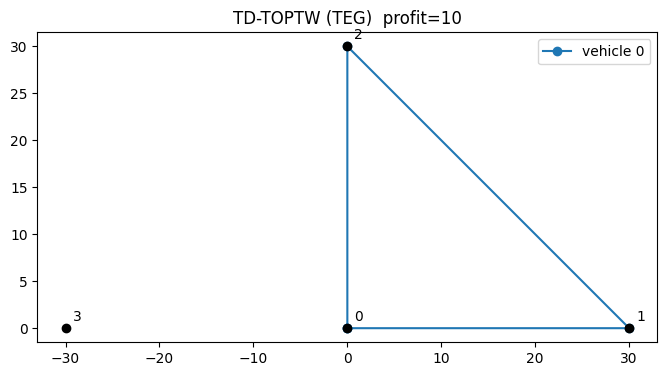

In [5]:
plot_routes(points, td.routes, title=f"TD-TOPTW (TEG)  profit={td.total_profit}")

## 4. What if we ignored time-of-day?

The static `solve_toptw_ilp` only sees a single matrix. Hand it the afternoon-slow matrix (the conservative thing to do if you assume the worst) and watch profit collapse — the budget can't fit any route under slow travel.

In [6]:
conservative = solve_toptw_ilp(
    distance=afternoon,
    profits=profits,
    time_windows=windows,
    num_vehicles=1,
    t_max=T_MAX,
    service_time=SERVICE,
    horizon=HORIZON,
    time_limit_seconds=10,
)

print(f"conservative (afternoon-only) profit : {conservative.total_profit}")
print(f"TEG (sees both shifts)        profit : {td.total_profit}")
print(f"value of seeing time-dependence      : +{td.total_profit - conservative.total_profit}")

conservative (afternoon-only) profit : 0
TEG (sees both shifts)        profit : 10
value of seeing time-dependence      : +10


## 5. What helps as this scales up

The TEG encoding is clean but its variable count is $O(K \cdot |\text{arcs}|)$. For our toy: a few hundred arcs. For $N = 30$ customers, $T = 100$ time points, $K = 4$ shifts the unfiltered arc count is on the order of $10^5$ per vehicle — CP-SAT will start struggling. The literature attacks this from several angles.

### 5.1 Column generation / branch-and-price

The headline technique for TOPTW at scale. Reformulate the master problem with one binary variable per **route** (a column) instead of per arc:

$$
\max \sum_r p_r \, \lambda_r \quad \text{s.t.}\quad \sum_{r \ni i} \lambda_r \leq 1 \;\forall i, \;\;\; \sum_r \lambda_r \leq K, \;\;\; \lambda_r \in \{0, 1\}
$$

There are exponentially many feasible routes, so we don't enumerate them. Instead the **pricing subproblem** uses LP duals from the relaxed master to generate the next promising column. The pricing problem is a **resource-constrained shortest path (ESPPRC)** on the TEG with reduced costs $\bar c_r = -p_r + \sum_{i \in r} \pi_i$. Labeling algorithms (Desrochers–Soumis, decremental state-space relaxation) or a small CP-SAT model solve it.

Time-dependent travel is *natural* in this framing because the pricing subproblem already runs on the TEG — adding "shift" to the resource vector is one extra label dimension.

For satellites, each column is a "schedule for one orbital pass". The master picks which passes to take given target priorities; the pricing problem schedules a single pass optimally given current dual prices. Extremely natural decomposition.

### 5.2 Piecewise-constant ILP (alternative encoding)

Keep the continuous $t_{i,k}$ variable from `solve_toptw_ilp`. For each arc $(i, j)$ introduce $K$ binary indicators $s_{ijk}^{\tau}$ that fire when $t_{i,k}$ falls in shift $\tau$. The propagation constraint then becomes

$$
x_{ijk} = 1 \;\wedge\; s_{ijk}^{\tau} = 1 \;\Rightarrow\; t_{j,k} \geq t_{i,k} + s_i + d_{ij}^{\tau}
$$

Compared with TEG: fewer variables (no node-time copies), more disjunctions (one per shift per arc). Worth it when $T$ is much larger than $K$.

### 5.3 ALNS / metaheuristics

Around $N \geq 100$ exact methods stall and **Adaptive Large Neighborhood Search** takes over. Destroy-and-repair operators:

- *Random removal*, *worst removal* (drop the lowest-profit-per-time customer), *shift removal* (drop everyone in one shift band).
- *Greedy insert*, *regret-k insert*.

A simulated-annealing acceptance loop drives this; operator weights adapt to which moves are succeeding. Loses optimality guarantees but routinely beats MILP wall-clock on $N \geq 200$ instances.

### 5.4 Lagrangian relaxation

Multiply the visit-at-most-once constraints into the objective with multipliers $\mu_i \geq 0$. The remaining problem **decomposes per vehicle** — each vehicle solves an orienteering problem on the TEG independently. Subgradient updates on $\mu_i$ tighten the bound; a primal heuristic recovers a feasible schedule.

Useful as a bound for branch-and-bound, less common as a stand-alone solver.

## 6. Takeaway

| problem size | recommended tool |
|---|---|
| $N \leq 12$, exact, time-dependent | TEG ILP (this notebook) |
| $N \leq 30$, exact, time-dependent | piecewise-constant ILP — fewer vars than TEG |
| $N \leq 200$, exact, time-dependent | column generation / branch-and-price |
| $N \geq 200$, near-optimal, fast | ALNS + a column-generation warm start |

For the satellite scheduling problem: the TEG formulation is the right thing to *understand* the dependency structure, but the working solver will almost certainly be column generation with a domain-aware pricing subproblem. The fact that "pricing = best schedule on one pass given target dual prices" mirrors the physical decomposition (one orbit = one route) is the strongest argument for the approach.